# INFERENCE PIPELINE

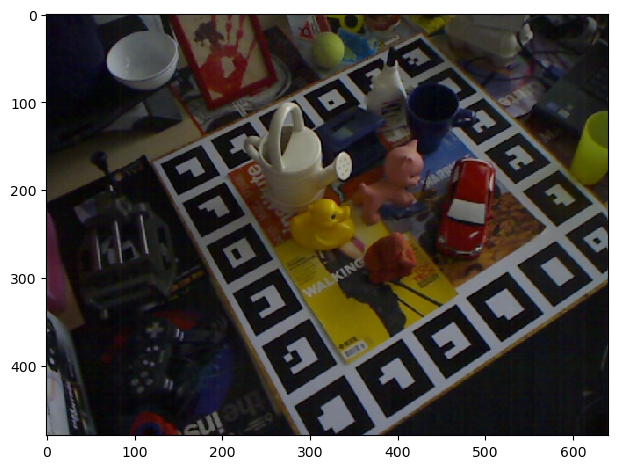

In [29]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt, random, math, statistics, os
from skimage.io import imshow


def showImage(img): # displays image using plt
	plt.figure()
	imshow(np.squeeze(img))
	plt.show()
from PIL import Image
height = 480
width = 640
filePath= r"/home/bradhakrishnan/Project/Linemod_preprocessed/data/06/rgb/0200.png"
image = Image.open(filePath)
image = image.resize((width, height))
    
showImage(image)

In [30]:

def show_prediction(image, pred, threshold=0.5):
    image_np = image.mul(255).permute(1, 2, 0).byte().cpu().numpy()
    image_cv = image_np.copy()

    for i in range(len(pred["boxes"])):
        score = pred["scores"][i].item()
        if score < threshold:
            continue
        box = pred["boxes"][i].detach().cpu().numpy().astype(np.int32)
        mask = pred["masks"][i, 0].detach().cpu().numpy()
        mask = (mask > 0.5).astype(np.uint8)

        # Apply mask
        colored_mask = np.zeros_like(image_cv)
        colored_mask[:, :, 1] = mask * 255  # Green mask
        image_cv = cv2.addWeighted(image_cv, 1.0, colored_mask, 0.5, 0)

        # Draw box
        cv2.rectangle(image_cv, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)

        # Add score text
        cv2.putText(image_cv, f"{score:.2f}", (box[0], box[1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (36,255,12), 1)

    # Show result
    plt.figure(figsize=(8, 8))
    plt.imshow(image_cv)
    plt.axis('off')
    plt.show()


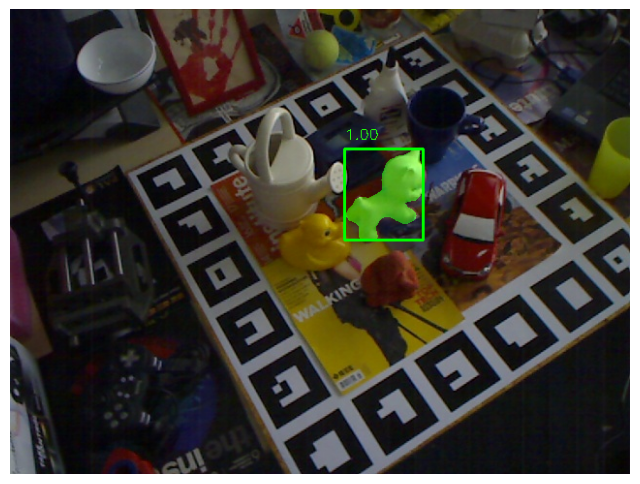

In [31]:
import torch
import torchvision
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
import cv2

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=False)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, 2)
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    in_features_mask, hidden_layer, 2)

# Load weights
model.load_state_dict(torch.load("LINEMOD_mask_rcnn.pth", map_location=device))
model.to(device)
model.eval()

image_tensor = F.to_tensor(image).to(device)  # Converts to float32 and normalizes to [0, 1]

model.eval()
with torch.no_grad():
    prediction = model([image_tensor])[0]  # Batch of 1 image

show_prediction(image_tensor, prediction)

classPred = prediction['masks'][0].permute(1, 2, 0).cpu().numpy()
mask_to_save = (classPred.squeeze() * 255).astype(np.uint8)  # shape: (480, 640)

Image.fromarray(mask_to_save).save("LINEMOD_PIPELINE_SEGMENTATION_OP.png")

In [32]:
import models_v2
import models
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1' 

nnInput = np.array([image])

vecModel = models_v2.pvNET(outVectors = True)
models_v2.joinFiles('/home/bradhakrishnan/Project/pv_tf/models/PVNET_LINEMOD_cat', vecModel) # loading weights for vector model
vecModel.compile(optimizer = tf.keras.optimizers.legacy.Adam(), loss = tf.keras.losses.Huber())

vecPred = vecModel.predict(nnInput)[0]

print("Vector Prediction shape: " + str(vecPred.shape))
print("Class Prediction shape: " + str(classPred.shape))
showImage(classPred)

population = np.where(classPred > .9)[:2]
population = list(zip(population[0], population[1]))

print(len(population)) # the number of class pixels found

Found 2 part files: /home/bradhakrishnan/Project/pv_tf/models/PVNET_LINEMOD_cat.part-0, /home/bradhakrishnan/Project/pv_tf/models/PVNET_LINEMOD_cat.part-1


Exception: Error joining files: Error loading model weights: Read less bytes than requested

In [ ]:
# REF: chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://www.cs.rice.edu/~vo9/vision/slides/lecture08-RANSAC.pdf
# REF: chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://www.cs.cornell.edu/courses/cs5670/2021sp/lectures/lec09_ransac_for_web.pdf


def ransacVal(y1, x1, v2): 
	v2 = v2 / np.linalg.norm(v2)
	
	return y1 * v2[1] + x1 * v2[0]

hypDict = {0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: []}

for n in range(50): #take two pixels, find intersection of unit vectors
    #print(n)
    p1 = population.pop(random.randrange(len(population)))
    v1 = vecPred[p1[0]][p1[1]]
    p2 = population.pop(random.randrange(len(population)))
    v2 = vecPred[p2[0]][p2[1]]
    for i in range(9):
         # find lines intersection
        m1 = v1[i * 2 + 1] / v1[i * 2]
        m2 = v2[i * 2 + 1] / v2[i * 2]
        b1 = p1[0] - p1[1] * m1
        b2 = p2[0] - p2[1] * m2
        x = (b2 - b1) / (m1 - m2)
        y = m1 * x + b1
        if (y >= p1[0] != v1[i * 2 + 1] < 0 or x >= p1[1] != v1[i * 2] < 0 or y >= p2[0] != v2[i * 2 + 1] < 0 or x >= p2[1] != v2[i * 2] < 0) or not (m1 - m2): # check if line intersection takes place according to unit vector directions
            continue
        #print(y, x)
        weight = 0
        for voter in population: # voting for fit of hypothesis
            yDiff = y - voter[0]
            xDiff = x - voter[1]

            mag = math.sqrt(yDiff ** 2 + xDiff ** 2)
            vec = vecPred[voter[0]][voter[1]][i * 2: i * 2 + 2]

            if ransacVal(yDiff / mag, xDiff / mag, vec) > .99:
                weight += 1
        hypDict[i].append(((y, x), weight))

    population.append(p1)
    population.append(p2)
    
print("Coordinate hypotheses and weights: " + str(hypDict[0]))

In [ ]:
def pruneHypsStdDev(hypDict, m = 2): # prune generated hypotheses using mean and stdDev
	for key, hyps in hypDict.items():
		yVals, xVals = [x[0][0]for x in hyps], [x[0][1]for x in hyps]
		yMean, xMean = statistics.mean(yVals), statistics.mean(xVals)
		yDev, xDev = statistics.pstdev(yVals) * m, statistics.pstdev(xVals) * m
		hypDict[key] = [x for x in hyps if not determineOutlier(x[0], yMean, yDev, xMean, xDev)]
        
def determineOutlier(input, yMean, yDev, xMean, xDev):
	return abs(input[0] - yMean) > yDev or abs(input[1] - xMean) > xDev
        
pruneHypsStdDev(hypDict)

In [ ]:
def getMean(hypDict): # get weighted average of coordinates
	meanDict = {}
	for key, hyps in hypDict.items():
		xMean = 0
		yMean = 0
		totalWeight = 0
		for hyp in hyps:
			yMean += hyp[0][0] * hyp[1]
			xMean += hyp[0][1] * hyp[1]
			totalWeight += hyp[1]
		yMean /= totalWeight
		xMean /= totalWeight
		meanDict[key] = [yMean, xMean]
	return meanDict

meanDict = getMean(hypDict)

print(meanDict)

In [ ]:
def dictToArray(hypDict): # take dictionary keypoints and return list object
	coordArray = np.zeros((len(hypDict.keys()), 2))
	for key, hyps in hypDict.items():
		coordArray[key] = np.array([round(hyps[1]), round(hyps[0])]) # x, y format
	return coordArray

pts3d = np.loadtxt('/home/bradhakrishnan/Project/stvNet/LINEMOD/cat/bb8_3d.txt')
preds = dictToArray(meanDict)[1:] # ignoring centroid prediction
matrix = np.array([[572.4114, 0., 325.2611], [0., 573.57043, 242.04899], [0., 0., 1.]]) #  input camera matrix for the kinect camera

import cv2

_, rVec, tVec = cv2.solvePnP(pts3d, preds, matrix, np.zeros(shape=[8, 1], dtype='float64'), flags = cv2.SOLVEPNP_ITERATIVE)

print("Rotation Vector: " + str(rVec)) # output rotation vector
print("Translation Vector: " + str(tVec)) # output translation vector

In [ ]:
labels= np.loadtxt('/home/bradhakrishnan/Project/LINEMOD/LINEMOD/cat/labels/000200.txt')[1:19]
labels[::2] *= 640
labels[1::2] *= 480
labels=np.array(labels).reshape(-1, 2)

In [ ]:
yPred = cv2.projectPoints(pts3d, rVec, tVec, matrix, np.zeros(shape=[8, 1], dtype='float64'))[0]
yPred = np.squeeze(yPred)

yTrue = labels

print("Keypoint pixel predictions: " + str(yPred))
print("Keypoint ground truth: " + str(yTrue))


def labelDrawPoints(drawList): # (b, f = back, front), (l, r = left, right), (u, d = up , down)
	drawDict = {}
	drawDict['bld'] = (int(round(drawList[0][0])), int(round(drawList[0][1])))
	drawDict['blu'] = (int(round(drawList[1][0])), int(round(drawList[1][1])))
	drawDict['fld'] = (int(round(drawList[2][0])), int(round(drawList[2][1])))
	drawDict['flu'] = (int(round(drawList[3][0])), int(round(drawList[3][1])))
	drawDict['brd'] = (int(round(drawList[4][0])), int(round(drawList[4][1])))
	drawDict['bru'] = (int(round(drawList[5][0])), int(round(drawList[5][1])))
	drawDict['frd'] = (int(round(drawList[6][0])), int(round(drawList[6][1])))
	drawDict['fru'] = (int(round(drawList[7][0])), int(round(drawList[7][1])))
	return drawDict

def drawPose(img, drawPoints, colour = (255,0,0)): # draw bounding box
	
	cv2.line(img, drawPoints['bld'], drawPoints['blu'], colour, 2)
	cv2.line(img, drawPoints['bld'], drawPoints['fld'], colour, 2)
	cv2.line(img, drawPoints['bld'], drawPoints['brd'], colour, 2)
	cv2.line(img, drawPoints['blu'], drawPoints['flu'], colour, 2)
	cv2.line(img, drawPoints['blu'], drawPoints['bru'], colour, 2)
	cv2.line(img, drawPoints['fld'], drawPoints['flu'], colour, 2)
	cv2.line(img, drawPoints['fld'], drawPoints['frd'], colour, 2)
	cv2.line(img, drawPoints['flu'], drawPoints['fru'], colour, 2)
	cv2.line(img, drawPoints['fru'], drawPoints['bru'], colour, 2)
	cv2.line(img, drawPoints['fru'], drawPoints['frd'], colour, 2)
	cv2.line(img, drawPoints['frd'], drawPoints['brd'], colour, 2)
	cv2.line(img, drawPoints['brd'], drawPoints['bru'], colour, 2)

img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
drawPose(img, labelDrawPoints(yPred)) #  drawing our predicted bounding box in blue
drawPose(img, labelDrawPoints(yTrue), (0,255,0)) # drawing the true bounding box in green
showImage(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

print("Prediction Accuracy - MAE: {0}, MSE {1}".format(round(tf.reduce_mean(tf.keras.metrics.mean_absolute_error(yTrue, yPred)).numpy(), 2), round(tf.reduce_mean(tf.keras.metrics.mean_squared_error(yTrue, yPred)).numpy(), 2)))

In [ ]:
# 2D projection error
import numpy as np
from plyfile import PlyData

def load_ply_model(ply_path):
    plydata = PlyData.read(ply_path)
    vertices = plydata['vertex']
    points_3d = np.stack([vertices['x'], vertices['y'], vertices['z']], axis=-1)
    return points_3d  # Shape: (N, 3)
def project_points(points_3d, K, R, t):
    """
    Projects 3D points into the image using the pose and camera intrinsics.
    """
    assert points_3d.shape[1] == 3
    t = t.reshape(3, 1)
    points_cam = (R @ points_3d.T) + t  # (3, N)
    points_proj = K @ points_cam  # (3, N)
    points_proj = points_proj[:2, :] / points_proj[2, :]  # Normalize by Z
    return points_proj.T  # (N, 2)
def compute_2d_projection_error(points_3d, K, R_pred, t_pred, R_gt, t_gt):
    proj_pred = project_points(points_3d, K, R_pred, t_pred)
    proj_gt = project_points(points_3d, K, R_gt, t_gt)
    errors = np.linalg.norm(proj_pred - proj_gt, axis=1)
    return np.mean(errors), errors  # mean error, all errors
def compute_2d_projection_accuracy(points_3d, K, R_pred, t_pred, R_gt, t_gt, threshold=5.0):
    mean_error, _ = compute_2d_projection_error(points_3d, K, R_pred, t_pred, R_gt, t_gt)
    return mean_error < threshold
    
ply_path = "/home/bradhakrishnan/Project/pv_tf/LINEMOD/cat/cat.ply"
points_3d = load_ply_model(ply_path)
PSOE = np.load('/home/bradhakrishnan/Project/LINEMOD/LINEMOD/cat/pose/pose200.npy')

# Dummy data (replace with actual data)
K =  np.array([[572.4114, 0., 325.2611], [0., 573.57043, 242.04899], [0., 0., 1.]])
R_pred,_ = cv2.Rodrigues(rVec)  # (3, 3)
t_pred = tVec  # (3,)
R_gt =   PSOE[:,:3]  # (3, 3)
t_gt =   PSOE[:,3:]  # (3,)

mean_err, _ = compute_2d_projection_error(points_3d, K, R_pred, t_pred, R_gt, t_gt)
print("Mean 2D projection error:", mean_err)

is_correct = compute_2d_projection_accuracy(points_3d, K, R_pred, t_pred, R_gt, t_gt,threshold=10)
print("Correct under 5px threshold:", is_correct)
